Continuation: delta=0.2, alpha=beta=100 -> OK
Continuation: delta=0.2, alpha=beta=1000 -> OK
Continuation: delta=0.2, alpha=beta=10000 -> OK
Solved delta=0.2 -> max|u'|=1.44e+03, clip_rate=0
Solved delta=0.1 -> max|u'|=2.35e+03, clip_rate=0
Solved delta=0.05 -> max|u'|=3.7e+03, clip_rate=0
Solved delta=0.025 -> max|u'|=5.68e+03, clip_rate=0


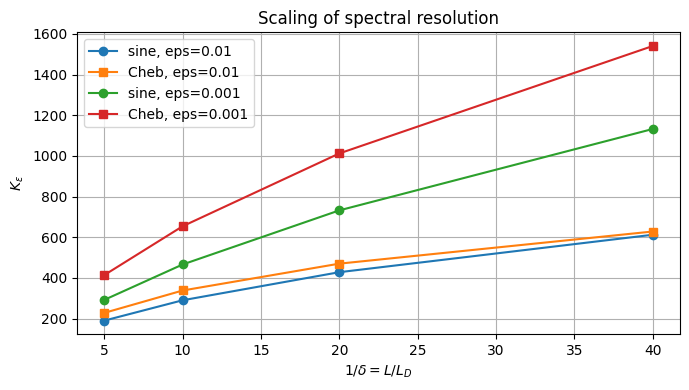

Saved: results.csv, results_table.tex, scaling_plot.pdf/png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
from scipy.fft import dst, dct

# -----------------------------
# Model utilities
# -----------------------------
def bulk_levels(alpha, beta):
    # neutrality: 2*sinh(u_p)=-alpha, 2*sinh(u_n)=beta
    u_p = np.arcsinh(-alpha / 2.0)
    u_n = np.arcsinh(beta / 2.0)
    return u_p, u_n

def doping_C_smooth(s, alpha, beta, eta=5e-3):
    """
    Smoothed step:
        C(s) ~ -alpha for s<<0,  C(s) ~ +beta for s>>0
    """
    return 0.5 * (beta - alpha) + 0.5 * (beta + alpha) * np.tanh(s / eta)

def clustered_mesh(N=900, a=4.5):
    """
    Mesh clustered near 0 using tanh map.
    a controls clustering strength.
    """
    t = np.linspace(-a, a, N)
    s = np.tanh(t) / np.tanh(a)   # maps to [-1,1]
    return s

def initial_guess_tanh(s, u_p, u_n, delta):
    """
    Good initial guess: tanh transition of width ~ delta.
    """
    mid = 0.5 * (u_p + u_n)
    amp = 0.5 * (u_n - u_p)
    width = max(delta, 1e-3)
    u0 = mid + amp * np.tanh(s / width)
    up0 = np.gradient(u0, s)
    return np.vstack([u0, up0])

# -----------------------------
# PB-BVP solver (robust)
# -----------------------------
def solve_pb_bvp(
    delta, alpha, beta,
    s_mesh,
    y_init=None,
    tol=1e-6,
    max_nodes=1_200_000,
    eta_C=5e-3,
    clip_lo=-60.0, clip_hi=60.0,
    verbose=0
):
    """
    Solve: -delta^2 u''(s) = exp(-u)-exp(u)+C(s) = -2*sinh(u)+C(s), s in (-1,1)
    BC: u(-1)=u_p, u(1)=u_n
    """
    u_p, u_n = bulk_levels(alpha, beta)

    if y_init is None:
        y_init = initial_guess_tanh(s_mesh, u_p, u_n, delta)

    clip_hits = {"count": 0, "total": 0}

    def fun(s, y):
        u = y[0]
        up = y[1]

        u_safe = np.clip(u, clip_lo, clip_hi)
        clip_hits["count"] += int(np.sum(u_safe != u))
        clip_hits["total"] += u.size

        C = doping_C_smooth(s, alpha, beta, eta=eta_C)

        # numerically stable form
        rhs = -2.0 * np.sinh(u_safe) + C
        upp = -(1.0 / (delta**2)) * rhs
        return np.vstack([up, upp])

    def bc(ya, yb):
        return np.array([ya[0] - u_p, yb[0] - u_n])

    sol = solve_bvp(fun, bc, s_mesh, y_init, tol=tol, max_nodes=max_nodes, verbose=verbose)
    if not sol.success:
        raise RuntimeError(f"solve_bvp failed: {sol.message}")

    # Evaluate on fine grid
    s_fine = np.linspace(-1.0, 1.0, 8000)
    u_fine, up_fine = sol.sol(s_fine)[0], sol.sol(s_fine)[1]
    clip_rate = (clip_hits["count"] / max(1, clip_hits["total"])) if clip_hits["total"] else 0.0

    return sol, s_fine, u_fine, up_fine, u_p, u_n, float(clip_rate)

def solve_two_stage(delta, alpha, beta, s_mesh, y0, eta_C, verbose=0):
    """
    Two-stage solve: coarse then refine.
    This prevents max_nodes errors and singular Jacobians in most cases.
    """
    # stage 1 (coarse)
    sol1, *_ = solve_pb_bvp(
        delta, alpha, beta,
        s_mesh=s_mesh,
        y_init=y0,
        tol=1e-4,
        max_nodes=1_200_000,
        eta_C=eta_C,
        verbose=verbose
    )
    y1 = np.vstack([sol1.sol(s_mesh)[0], sol1.sol(s_mesh)[1]])

    # stage 2 (refine)
    sol2, s, u, up, u_p, u_n, clip_rate = solve_pb_bvp(
        delta, alpha, beta,
        s_mesh=s_mesh,
        y_init=y1,
        tol=1e-7,
        max_nodes=1_200_000,
        eta_C=eta_C,
        verbose=verbose
    )
    return sol2, s, u, up, u_p, u_n, clip_rate

# -----------------------------
# Spectral diagnostics
# -----------------------------
def sine_coeffs_zero_bc(s, u, u_p, u_n, N_dst=16384):
    """
    Compute sine coefficients for w=u-u_lin with w(+-1)=0 using DST-I.
    """
    t = np.linspace(0.0, 1.0, N_dst + 2)
    s_uni = 2.0 * t - 1.0
    u_uni = np.interp(s_uni, s, u)

    # remove linear profile so w endpoints are zero
    u_lin = u_p + (u_n - u_p) * t
    w = u_uni - u_lin

    # interior points for DST-I
    w_int = w[1:-1]
    A = dst(w_int, type=1)
    a = 2.0 * A / (N_dst + 1)   # scaling consistent with DST-I orthogonality on uniform grid

    ak2 = np.abs(a)**2
    total = float(ak2.sum())
    tail = np.cumsum(ak2[::-1])[::-1]
    return a, tail, total

def cheb_coeffs(s, u, N_cheb=4096):
    """
    Chebyshev coefficients via DCT-I on Chebyshev grid.
    """
    j = np.arange(N_cheb + 1)
    x = np.cos(np.pi * j / N_cheb)    # in [-1,1]
    u_x = np.interp(x, s, u)

    C = dct(u_x, type=1)
    c = C / N_cheb
    c[0] *= 0.5
    c[-1] *= 0.5

    ck2 = np.abs(c)**2
    total = float(ck2.sum())
    tail = np.cumsum(ck2[::-1])[::-1]
    return c, tail, total

def K_eps_from_tail(tail, total, eps=1e-3):
    """
    Smallest K such that tail_energy <= eps^2 * total_energy.
    tail array is indexed by k=0..(len-1) where tail[k]=sum_{j>=k} |coef_j|^2
    For sine series, our coef indexing is 1..N_dst but stored 0..N_dst-1;
    returning K in that same 1..N sense is not crucial; we report array index.
    """
    thresh = (eps**2) * total
    idx = np.where(tail <= thresh)[0]
    if len(idx) == 0:
        return int(len(tail) - 1)
    return int(idx[0])

# -----------------------------
# Export
# -----------------------------
def save_results_csv(results, path="results.csv"):
    import csv
    keys = list(results[0].keys())
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=keys)
        w.writeheader()
        for r in results:
            w.writerow(r)

def save_results_table_tex(results, eps_list, path="results_table.tex"):
    headers = ["delta", "1/delta", "max|u'|", "clip_rate", "N_dst", "N_cheb"] + \
              [f"Ksin({eps:g})" for eps in eps_list] + \
              [f"Kcheb({eps:g})" for eps in eps_list]

    lines = []
    lines.append("\\begin{tabular}{rrrrrr" + "r"*(2*len(eps_list)) + "}")
    lines.append("\\toprule")
    lines.append(" & ".join(headers) + " \\\\")
    lines.append("\\midrule")
    for r in results:
        row = [
            f"{r['delta']:.5g}",
            f"{(1.0/r['delta']):.5g}",
            f"{r['max_slope']:.5g}",
            f"{r['clip_rate']:.3g}",
            f"{int(r['N_dst'])}",
            f"{int(r['N_cheb'])}",
        ]
        for eps in eps_list:
            row.append(str(int(r[f"Ksin_{eps:g}"])))
        for eps in eps_list:
            row.append(str(int(r[f"Kcheb_{eps:g}"])))
        lines.append(" & ".join(row) + " \\\\")
    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

# -----------------------------
# Main experiment (continuation in alpha then delta)
# -----------------------------
def run_experiment():
    # Target alphas/betas for paper runs
    alpha_target = 1e4
    beta_target  = 1e4

    # Continuation ladder for alpha,beta (helps solver a lot)
    alpha_path = [1e2, 1e3, 1e4]  # ends at 1e4
    beta_path  = [1e2, 1e3, 1e4]

    deltas = [0.20, 0.10, 0.05, 0.025]
    eps_list = [1e-2, 1e-3]

    # spectral resolutions
    N_dst  = 16384
    N_cheb = 4096

    # solver settings
    eta_C = 5e-3          # smoothing width of step
    s_mesh = clustered_mesh(N=900, a=4.5)
    verbose = 0

    # --- Step A: continuation in alpha/beta at delta=0.2 to get a strong initial profile
    delta0 = deltas[0]
    sol_prev = None

    for a, b in zip(alpha_path, beta_path):
        u_p, u_n = bulk_levels(a, b)
        if sol_prev is None:
            y0 = initial_guess_tanh(s_mesh, u_p, u_n, delta0)
        else:
            y_prev = sol_prev.sol(s_mesh)
            y0 = np.vstack([y_prev[0], y_prev[1]])

        sol_prev, *_ = solve_two_stage(delta0, a, b, s_mesh, y0, eta_C, verbose=verbose)
        print(f"Continuation: delta={delta0}, alpha=beta={a:g} -> OK")

    # Ensure we are at requested target alpha/beta (in case paths differ)
    if alpha_path[-1] != alpha_target or beta_path[-1] != beta_target:
        u_p, u_n = bulk_levels(alpha_target, beta_target)
        y_prev = sol_prev.sol(s_mesh)
        y0 = np.vstack([y_prev[0], y_prev[1]])
        sol_prev, *_ = solve_two_stage(delta0, alpha_target, beta_target, s_mesh, y0, eta_C, verbose=verbose)
        print(f"Continuation: delta={delta0}, alpha=beta={alpha_target:g} -> OK")

    # --- Step B: sweep deltas with continuation in delta
    results = []

    for delta in deltas:
        if delta == delta0:
            y0 = np.vstack([sol_prev.sol(s_mesh)[0], sol_prev.sol(s_mesh)[1]])
        else:
            # reuse previous delta solution as init
            y0 = np.vstack([sol_prev.sol(s_mesh)[0], sol_prev.sol(s_mesh)[1]])

        sol, s, u, up, u_p, u_n, clip_rate = solve_two_stage(
            delta, alpha_target, beta_target, s_mesh, y0, eta_C, verbose=verbose
        )

        sol_prev = sol

        a_sin, tail_sin, total_sin = sine_coeffs_zero_bc(s, u, u_p, u_n, N_dst=N_dst)
        c_cheb, tail_cheb, total_cheb = cheb_coeffs(s, u, N_cheb=N_cheb)

        row = {
            "delta": float(delta),
            "max_slope": float(np.max(np.abs(up))),
            "clip_rate": float(clip_rate),
            "N_dst": int(N_dst),
            "N_cheb": int(N_cheb),
        }
        for eps in eps_list:
            row[f"Ksin_{eps:g}"]  = K_eps_from_tail(tail_sin, total_sin, eps)
            row[f"Kcheb_{eps:g}"] = K_eps_from_tail(tail_cheb, total_cheb, eps)

        results.append(row)
        print(f"Solved delta={delta:g} -> max|u'|={row['max_slope']:.3g}, clip_rate={row['clip_rate']:.3g}")

    # --- Export
    save_results_csv(results, "results.csv")
    save_results_table_tex(results, eps_list, "results_table.tex")

    # --- Plot scaling
    invd = np.array([1.0 / r["delta"] for r in results], dtype=float)

    plt.figure(figsize=(7, 4))
    for eps in eps_list:
        Ksin  = np.array([r[f"Ksin_{eps:g}"]  for r in results], dtype=float)
        Kcheb = np.array([r[f"Kcheb_{eps:g}"] for r in results], dtype=float)
        plt.plot(invd, Ksin,  marker='o', label=f'sine, eps={eps:g}')
        plt.plot(invd, Kcheb, marker='s', label=f'Cheb, eps={eps:g}')

    plt.xlabel(r'$1/\delta = L/L_D$')
    plt.ylabel(r'$K_\varepsilon$')
    plt.title('Scaling of spectral resolution')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("scaling_plot.pdf")
    plt.savefig("scaling_plot.png", dpi=200)
    plt.show()

    print("Saved: results.csv, results_table.tex, scaling_plot.pdf/png")
    return results

if __name__ == "__main__":
    run_experiment()